In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from torchvision import datasets, models
from torchvision.transforms import transforms

from captum.attr import IntegratedGradients, Occlusion
from sklearn.metrics import auc

In [2]:
model_path = Path("../models/resnet18_mnist_trained.pth")
data_path = Path("../data/")

In [3]:
def get_device():
    return torch.device("cuda")


def load_model(model_path, num_classes=10):
    device = get_device()

    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    state_dict = torch.load(Path(model_path), map_location=device)
    model.load_state_dict(state_dict)

    model = model.to(device)
    model.eval()

    return model


def get_test_data():
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    )

    return datasets.MNIST(
        root="../data", download=False, train=False, transform=transform
    )


def get_test_data_loader():
    return DataLoader(
        get_test_data(),
        batch_size=64,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
    )


def tensor_to_img(tensor):
    # Remove batch dimension (if exists) and move to CPU
    img_np = tensor.squeeze(0).detach().cpu().numpy()

    # Handle channel dimensions (C, H, W) -> (H, W, C)
    if img_np.ndim == 3:
        if img_np.shape[0] == 1:
            img_np = img_np.squeeze(0)  # Grayscale conversion
        else:
            img_np = np.transpose(img_np, (1, 2, 0))  # RGB conversion

    # Denormalize from [-1, 1] to [0, 1] for visual display
    img_np = (img_np + 1) / 2
    img_np = np.clip(img_np, 0, 1)

    return img_np


def process_attribution_raw(attr_tensor):
    attr_np = attr_tensor.squeeze(0).detach().cpu().numpy()

    if attr_np.ndim == 3:
        attr_np = np.sum(attr_np, axis=0)

    return attr_np


def plot_image(ax, img, title, cmap=None):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")


def cosine_sim(a, b):
    a = a.flatten()
    b = b.flatten()

    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)


def topk_iou(a, b, top_k_percent=0.10):
    a = a.flatten()
    b = b.flatten()

    k = int(len(a) * top_k_percent)

    # Top-K największych wartości RAW attribution
    top_a = np.argpartition(a, -k)[-k:]
    top_b = np.argpartition(b, -k)[-k:]

    set_a = set(top_a)
    set_b = set(top_b)

    intersection = len(set_a & set_b)
    union = len(set_a | set_b)

    return intersection / (union + 1e-8)


def deletion_auc(
    model,
    input_tensor,
    attribution_map,
    target_class,
    steps=20,
    baseline_value=-1.0,
):
    """
    Deletion AUC dla jednej próbki.

    Usuwa piksele według największych DODATNICH atrybucji,
    czyli tych, które wspierają target_class.
    """

    x_deleted = input_tensor.clone().detach()
    _, C, H, W = x_deleted.shape

    total_pixels = H * W

    # RAW attribution -> flatten
    attr_flat = attribution_map.flatten()

    # Bierzemy tylko dodatnie atrybucje jako importance
    # bo deletion ma usuwać piksele wspierające target class
    importance = np.maximum(attr_flat, 0)

    # Jeśli przypadkiem wszystko byłoby zerowe lub ujemne,
    # fallback na surowe wartości dodatnie nie zadziała, więc używamy abs awaryjnie
    if np.all(importance == 0):
        importance = np.abs(attr_flat)

    # Indeksy od najbardziej do najmniej ważnych
    sorted_indices = np.argsort(importance)[::-1]

    confidences = []
    fractions_removed = []

    with torch.no_grad():
        for step in range(steps + 1):
            fraction_removed = step / steps

            # Mierzymy confidence aktualnego obrazu
            output = model(x_deleted)
            prob = torch.softmax(output, dim=1)[0, target_class].item()

            confidences.append(prob)
            fractions_removed.append(fraction_removed)

            if step == steps:
                break

            start = int((step / steps) * total_pixels)
            end = int(((step + 1) / steps) * total_pixels)

            pixels_to_remove = sorted_indices[start:end]

            rows = pixels_to_remove // W
            cols = pixels_to_remove % W

            # Usuwamy piksele we wszystkich kanałach
            x_deleted[:, :, rows, cols] = baseline_value

    deletion_score = auc(fractions_removed, confidences)

    return deletion_score


def fgsm_attack(model, input_tensor, target_class, epsilon):
    device = get_device()
    x = input_tensor.clone().detach().to(device)
    x.requires_grad = True

    output = model(x)
    loss = torch.nn.functional.cross_entropy(
        output, torch.tensor([target_class], device=device)
    )

    model.zero_grad()
    loss.backward()

    perturbation = epsilon * x.grad.sign()
    x_adv = x + perturbation

    # bo obrazy masz w zakresie [-1, 1]
    x_adv = torch.clamp(x_adv, -1.0, 1.0)

    return x_adv.detach()

In [4]:
device = get_device()
model = load_model(model_path=model_path)
test_data = get_test_data()
test_data_loader = get_test_data_loader()
ig = IntegratedGradients(model)
occlusion = Occlusion(model)

In [5]:
epsilon = 0.5

clean_examples = {}
attacked_examples = {}

num_classes = 10

for image, label in test_data:
    if label not in clean_examples:
        clean_tensor = image.unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=label,
            epsilon=epsilon,
        )

        clean_examples[label] = image

        attacked_examples[label] = attacked_tensor.squeeze(0).detach().cpu()

    if len(clean_examples) == num_classes:
        break

In [6]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

all_attack_results = []

for epsilon in epsilon_values:
    attacked_examples = {}

    for digit in range(10):
        # CLEAN
        clean_tensor = clean_examples[digit].unsqueeze(0).to(device)

        # FGSM ATTACK
        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=digit,
            epsilon=epsilon,
        )

        attacked_examples[digit] = attacked_tensor.squeeze(0).detach().cpu()

        # PREDICTIONS
        with torch.no_grad():
            clean_output = model(clean_tensor)
            attacked_output = model(attacked_tensor)

            clean_pred = clean_output.argmax(dim=1).item()
            attacked_pred = attacked_output.argmax(dim=1).item()

            clean_conf = torch.softmax(clean_output, dim=1)[0, digit].item()

            attacked_conf = torch.softmax(attacked_output, dim=1)[0, digit].item()

        all_attack_results.append(
            {
                "Epsilon": epsilon,
                "Digit": digit,
                "CleanPred": clean_pred,
                "AttackedPred": attacked_pred,
                "PredictionChanged": clean_pred != attacked_pred,
                "CleanConfidence": clean_conf,
                "AttackedConfidence": attacked_conf,
            }
        )

# --- DATAFRAME ---
df_attack_results = pd.DataFrame(all_attack_results)

# --- PREDICTIONS TABLE ---
df_preds = df_attack_results.pivot(
    index="Epsilon",
    columns="Digit",
    values="AttackedPred",
)

# --- CONFIDENCE TABLE ---
df_conf = df_attack_results.pivot(
    index="Epsilon",
    columns="Digit",
    values="AttackedConfidence",
)

# --- COUNT CHANGED PREDICTIONS ---
df_pred_changes = df_attack_results.groupby("Epsilon")["PredictionChanged"].sum()

print("=== FGSM Predictions ===")
display(df_preds)

print("\n=== FGSM Confidence ===")
display(df_conf.round(3))

print("\n=== Prediction Changes ===")
display(df_pred_changes)

=== FGSM Predictions ===


Digit,0,1,2,3,4,5,6,7,8,9
Epsilon,,,,,,,,,,
0.001,0,1,2,3,4,5,6,7,8,9
0.005,0,1,2,3,4,5,6,7,8,9
0.010,0,1,2,3,4,5,6,7,8,9
0.050,0,1,2,3,4,5,6,7,8,9
0.100,0,1,2,3,4,6,6,7,8,9
0.500,9,1,4,4,4,6,0,2,9,4



=== FGSM Confidence ===


Digit,0,1,2,3,4,5,6,7,8,9
Epsilon,,,,,,,,,,
0.001,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.005,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.010,1.000,1.000,1.000,0.999,1.000,0.999,1.000,1.000,1.000,1.000
0.050,1.000,1.000,1.000,0.989,0.998,0.979,1.000,0.999,1.000,1.000
0.100,0.981,0.998,1.000,0.878,0.966,0.478,0.999,0.995,1.000,0.998
0.500,0.003,0.967,0.199,0.022,0.668,0.001,0.023,0.062,0.022,0.004



=== Prediction Changes ===


Epsilon
0.001    0
0.005    0
0.010    0
0.050    0
0.100    1
0.500    8
Name: PredictionChanged, dtype: int64

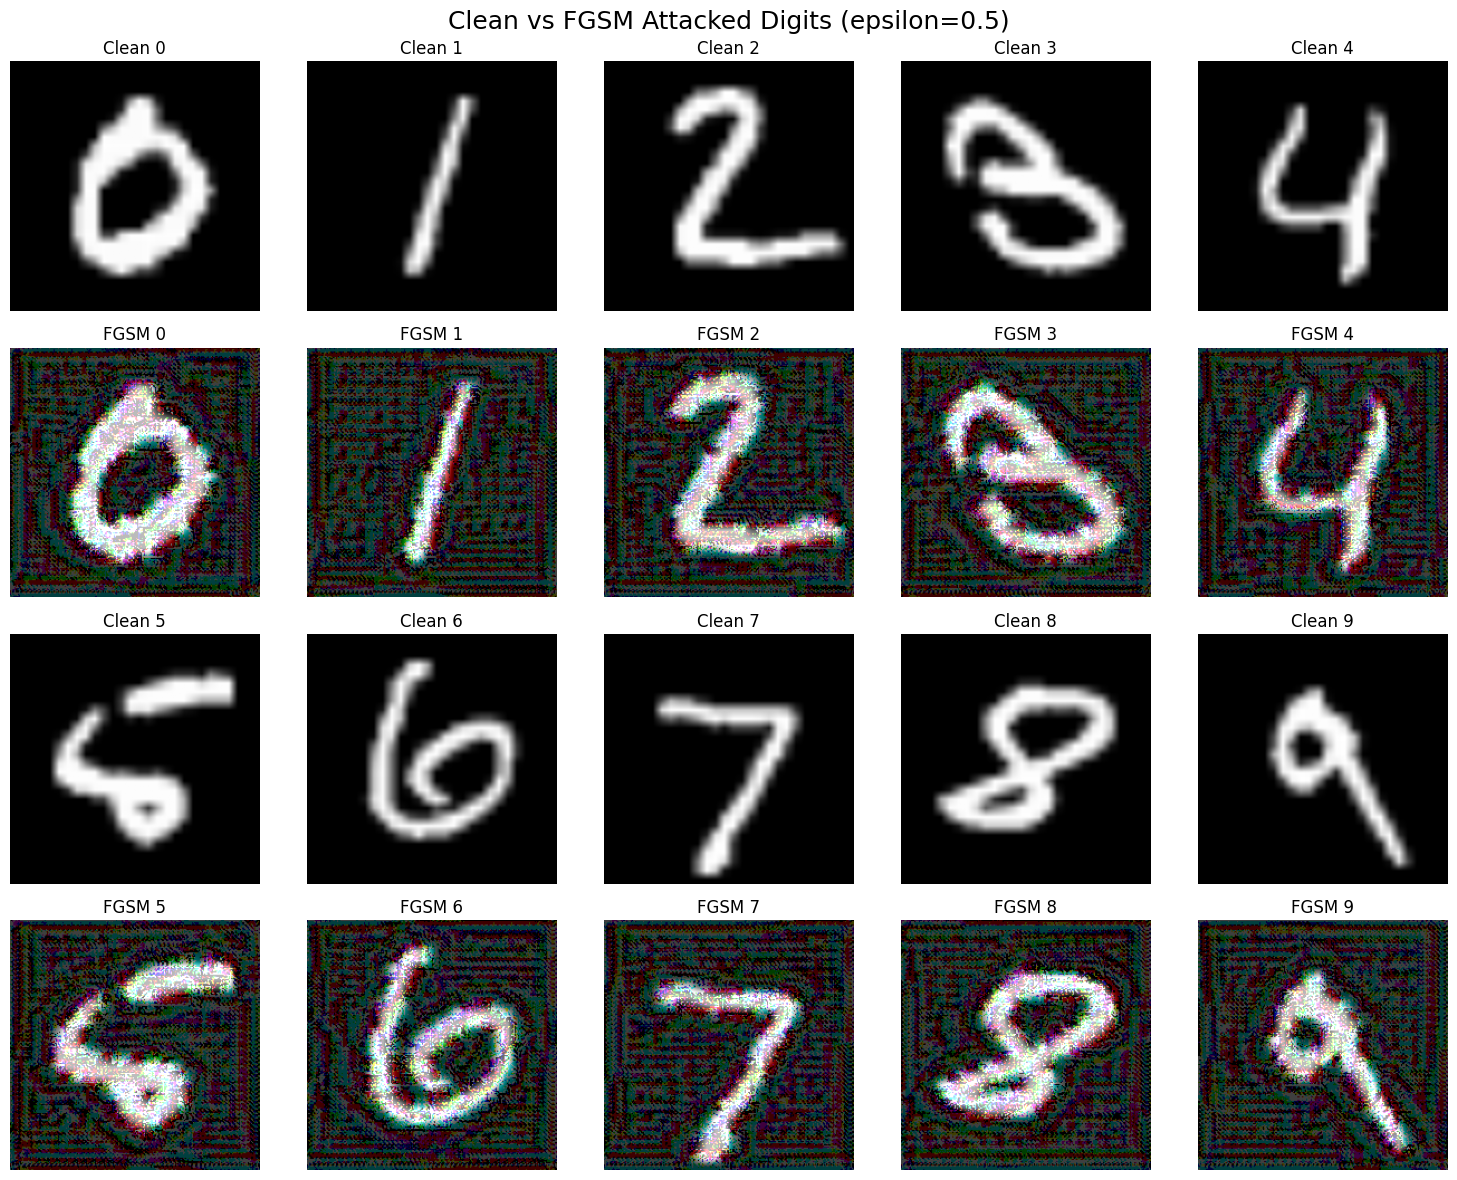

In [7]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle(f"Clean vs FGSM Attacked Digits (epsilon={epsilon})", fontsize=18)

for digit in range(10):
    col = digit % 5

    row_clean, row_attacked = (0, 1) if digit < 5 else (2, 3)

    clean_img = tensor_to_img(clean_examples[digit])
    attacked_img = tensor_to_img(attacked_examples[digit])

    cmap = "gray" if clean_img.ndim == 2 else None

    plot_image(axes[row_clean, col], clean_img, f"Clean {digit}", cmap)

    plot_image(axes[row_attacked, col], attacked_img, f"FGSM {digit}", cmap)

plt.tight_layout()
plt.show()

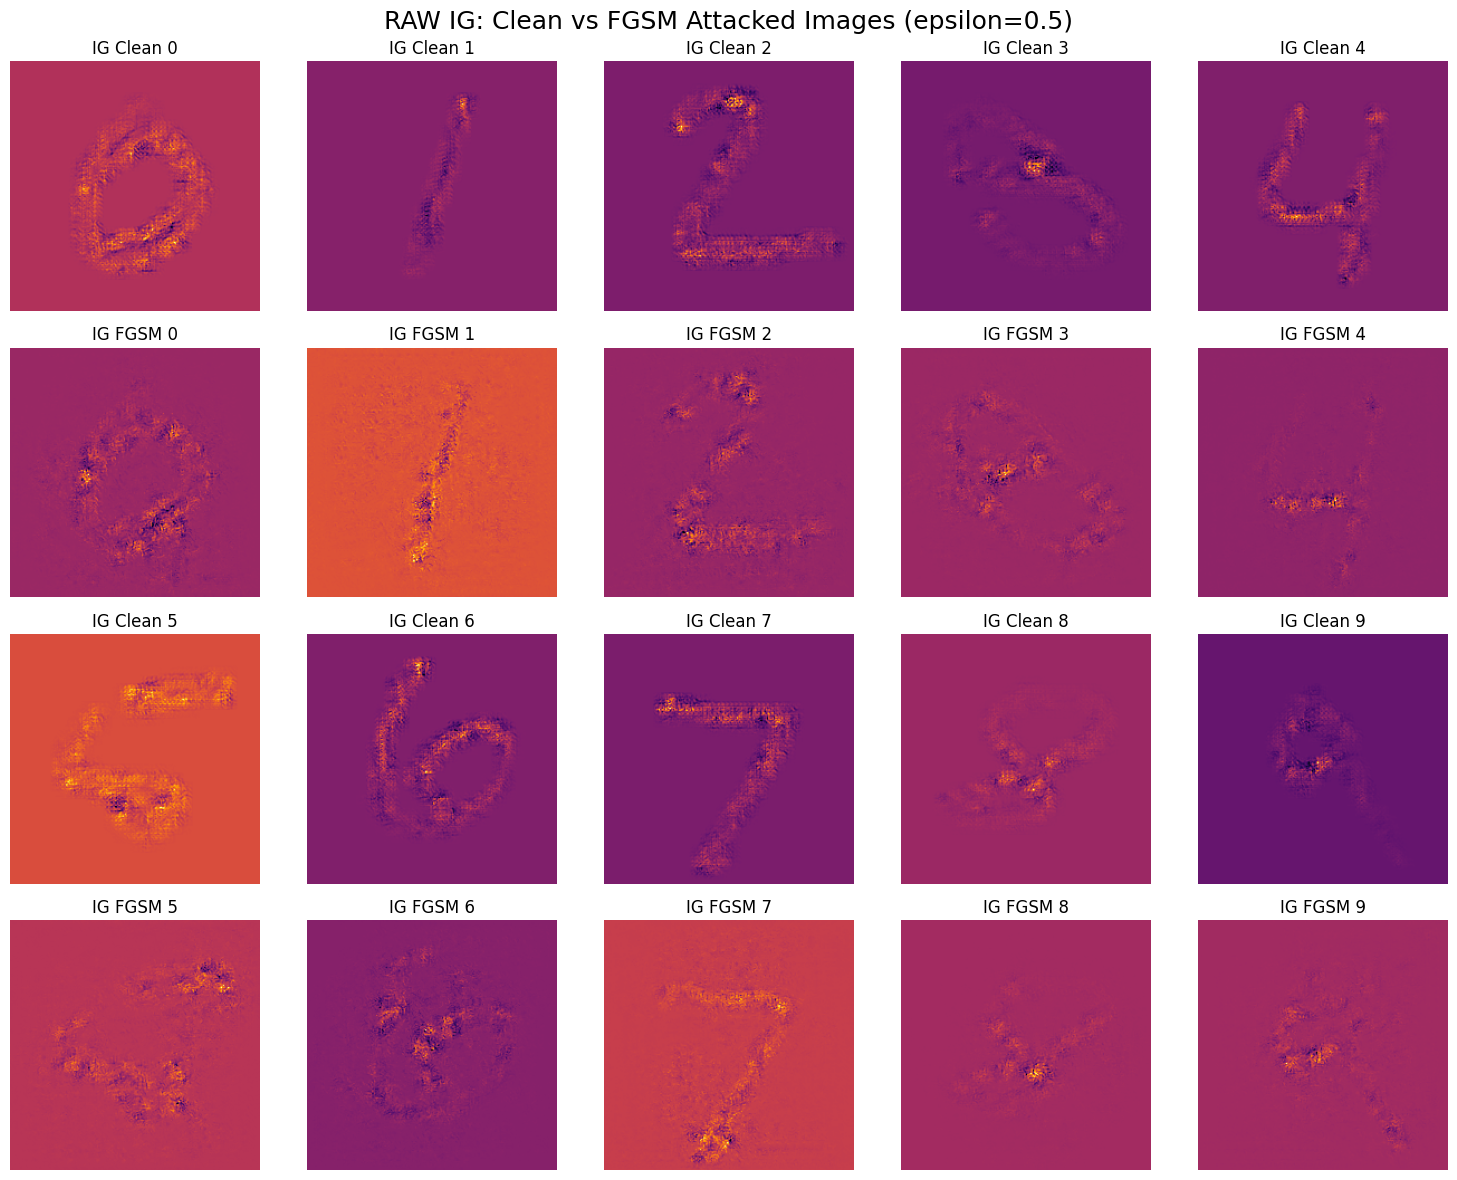

In [8]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle(f"RAW IG: Clean vs FGSM Attacked Images (epsilon={epsilon})", fontsize=18)

for digit in range(10):
    col = digit % 5

    if digit < 5:
        row_clean = 0
        row_attacked = 1
    else:
        row_clean = 2
        row_attacked = 3

    # --- CLEAN ---
    clean_tensor = clean_examples[digit].unsqueeze(0).to(device)

    baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)

    attr_clean_raw = ig.attribute(
        clean_tensor, baselines=baseline_clean, target=digit, n_steps=50
    )

    clean_attr_np = process_attribution_raw(attr_clean_raw)

    plot_image(
        axes[row_clean, col],
        clean_attr_np,
        title=f"IG Clean {digit}",
        cmap="inferno",
    )

    # --- FGSM ATTACKED ---
    attacked_tensor = attacked_examples[digit].unsqueeze(0).to(device)

    baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

    attr_attacked_raw = ig.attribute(
        attacked_tensor, baselines=baseline_attacked, target=digit, n_steps=50
    )

    attacked_attr_np = process_attribution_raw(attr_attacked_raw)

    plot_image(
        axes[row_attacked, col],
        attacked_attr_np,
        title=f"IG FGSM {digit}",
        cmap="inferno",
    )

plt.tight_layout()
plt.show()

### Cosine Similarity

In [9]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

all_digit_results = []

for epsilon in epsilon_values:
    for digit in range(10):
        # --- CLEAN ---
        clean_tensor = clean_examples[digit].unsqueeze(0).to(device)

        # --- FGSM ATTACKED ---
        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=digit,
            epsilon=epsilon,
        )

        # --- BASELINE ---
        baseline = torch.full_like(clean_tensor, -1.0).to(device)

        # --- IG CLEAN ---
        attr_clean_raw = ig.attribute(
            clean_tensor,
            baselines=baseline,
            target=digit,
            n_steps=50,
        )

        # --- IG ATTACKED ---
        attr_attacked_raw = ig.attribute(
            attacked_tensor,
            baselines=baseline,
            target=digit,
            n_steps=50,
        )

        # --- RAW ATTRIBUTIONS ---
        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        # --- RAW COSINE SIMILARITY ---
        score = cosine_sim(clean_attr_np, attacked_attr_np)

        all_digit_results.append(
            {
                "Epsilon": epsilon,
                "Digit": digit,
                "CosineSimilarity": score,
            }
        )

# --- DATAFRAME ---
df_cosine_all = pd.DataFrame(all_digit_results)

# --- SUMMARY ---
df_cosine_summary = (
    df_cosine_all.groupby("Epsilon")["CosineSimilarity"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "MeanCosineSimilarity",
            "std": "StdCosineSimilarity",
        }
    )
)

# --- PER DIGIT TABLE ---
df_cosine_pivot = df_cosine_all.pivot(
    index="Epsilon",
    columns="Digit",
    values="CosineSimilarity",
)

# --- DISPLAY ---
print("Per digit results:")
display(df_cosine_pivot.round(3))

print("\nSummary:")
display(df_cosine_summary.round(3))

Per digit results:


Digit,0,1,2,3,4,5,6,7,8,9
Epsilon,,,,,,,,,,
0.001,0.898,0.983,0.927,0.938,0.928,0.927,0.967,0.947,0.970,0.976
0.005,0.791,0.927,0.834,0.833,0.855,0.838,0.872,0.856,0.888,0.877
0.010,0.719,0.860,0.773,0.762,0.792,0.770,0.782,0.790,0.821,0.781
0.050,0.519,0.639,0.572,0.563,0.591,0.551,0.543,0.576,0.613,0.553
0.100,0.401,0.539,0.482,0.454,0.496,0.430,0.424,0.486,0.538,0.469
0.500,0.151,0.253,0.230,0.085,0.188,0.077,0.060,0.173,0.315,0.237



Summary:


,Epsilon,MeanCosineSimilarity,StdCosineSimilarity
0,0.001,0.946,0.027
1,0.005,0.857,0.037
2,0.010,0.785,0.037
3,0.050,0.572,0.035
4,0.100,0.472,0.046
5,0.500,0.177,0.084


### Top K IoU

In [10]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

all_iou_results = []

for epsilon in epsilon_values:
    for digit in range(10):
        # CLEAN
        clean_tensor = clean_examples[digit].unsqueeze(0).to(device)

        # FGSM ATTACKED
        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=digit,
            epsilon=epsilon,
        )

        # BASELINE
        baseline = torch.full_like(clean_tensor, -1.0).to(device)

        # IG CLEAN
        attr_clean_raw = ig.attribute(
            clean_tensor,
            baselines=baseline,
            target=digit,
            n_steps=50,
        )

        # IG ATTACKED
        attr_attacked_raw = ig.attribute(
            attacked_tensor,
            baselines=baseline,
            target=digit,
            n_steps=50,
        )

        # RAW MAPS
        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        # TOP-K IoU
        iou_score = topk_iou(
            clean_attr_np,
            attacked_attr_np,
            top_k_percent=0.10,
        )

        all_iou_results.append(
            {
                "Epsilon": epsilon,
                "Digit": digit,
                "TopK_IoU": iou_score,
            }
        )

# DataFrame
df_iou = pd.DataFrame(all_iou_results)

df_iou_pivot = df_iou.pivot(
    index="Epsilon",
    columns="Digit",
    values="TopK_IoU",
)

display(df_iou_pivot.round(3))

df_iou_summary = (
    df_iou.groupby("Epsilon")["TopK_IoU"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "MeanTopK_IoU", "std": "StdTopK_IoU"})
)

display(df_iou_summary.round(3))

Digit,0,1,2,3,4,5,6,7,8,9
Epsilon,,,,,,,,,,
0.001,0.799,0.423,0.822,0.836,0.874,0.817,0.883,0.892,0.870,0.912
0.005,0.673,0.377,0.711,0.700,0.757,0.701,0.726,0.772,0.742,0.770
0.010,0.608,0.344,0.652,0.624,0.680,0.629,0.649,0.712,0.661,0.694
0.050,0.476,0.253,0.496,0.471,0.506,0.479,0.478,0.536,0.507,0.500
0.100,0.413,0.214,0.449,0.412,0.420,0.426,0.407,0.469,0.457,0.420
0.500,0.266,0.130,0.296,0.207,0.232,0.221,0.198,0.265,0.280,0.204


,Epsilon,MeanTopK_IoU,StdTopK_IoU
0,0.001,0.813,0.142
1,0.005,0.693,0.116
2,0.010,0.625,0.104
3,0.050,0.470,0.079
4,0.100,0.409,0.072
5,0.500,0.230,0.049


### Deletion AUC

In [11]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]

all_deletion_results = []

for epsilon in epsilon_values:
    for digit in range(10):
        clean_tensor = clean_examples[digit].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=digit,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        with torch.no_grad():
            clean_output = model(clean_tensor)
            attacked_output = model(attacked_tensor)

            clean_pred = clean_output.argmax(dim=1).item()
            attacked_pred = attacked_output.argmax(dim=1).item()

            clean_conf = torch.softmax(clean_output, dim=1)[0, digit].item()
            attacked_conf = torch.softmax(attacked_output, dim=1)[0, digit].item()

        # IG względem prawdziwej klasy digit
        attr_clean_raw = ig.attribute(
            clean_tensor,
            baselines=baseline_clean,
            target=digit,
            n_steps=50,
        )

        attr_attacked_raw = ig.attribute(
            attacked_tensor,
            baselines=baseline_attacked,
            target=digit,
            n_steps=50,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        deletion_clean = deletion_auc(
            model=model,
            input_tensor=clean_tensor,
            attribution_map=clean_attr_np,
            target_class=digit,
            steps=20,
            baseline_value=-1.0,
        )

        deletion_attacked = deletion_auc(
            model=model,
            input_tensor=attacked_tensor,
            attribution_map=attacked_attr_np,
            target_class=digit,
            steps=20,
            baseline_value=-1.0,
        )

        all_deletion_results.append(
            {
                "Epsilon": epsilon,
                "Digit": digit,
                "CleanPred": clean_pred,
                "AttackedPred": attacked_pred,
                "CleanConfidence": clean_conf,
                "AttackedConfidence": attacked_conf,
                "PredictionChanged": clean_pred != attacked_pred,
                "DeletionAUC_Clean": deletion_clean,
                "DeletionAUC_Attacked": deletion_attacked,
            }
        )

df_deletion = pd.DataFrame(all_deletion_results)

df_deletion_attacked_pivot = df_deletion.pivot(
    index="Epsilon", columns="Digit", values="DeletionAUC_Attacked"
)

df_deletion_summary = df_deletion.groupby("Epsilon").agg(
    CleanAUC_Mean=("DeletionAUC_Clean", "mean"),
    CleanAUC_Std=("DeletionAUC_Clean", "std"),
    AttackedAUC_Mean=("DeletionAUC_Attacked", "mean"),
    AttackedAUC_Std=("DeletionAUC_Attacked", "std"),
    AttackedConfidence_Mean=("AttackedConfidence", "mean"),
    PredictionChanges=("PredictionChanged", "sum"),
)

print("=== FGSM Deletion AUC per digit ===")
display(df_deletion_attacked_pivot.round(3))

print("\n=== SUMMARY ===")
display(df_deletion_summary.round(3))

=== FGSM Deletion AUC per digit ===


Digit,0,1,2,3,4,5,6,7,8,9
Epsilon,,,,,,,,,,
0.001,0.763,0.997,0.093,0.068,0.099,0.114,0.501,0.100,0.088,0.028
0.005,0.762,0.997,0.087,0.061,0.117,0.106,0.467,0.100,0.081,0.027
0.010,0.746,0.997,0.086,0.049,0.102,0.069,0.451,0.097,0.096,0.028
0.050,0.738,0.994,0.069,0.035,0.100,0.060,0.395,0.076,0.049,0.027
0.100,0.488,0.991,0.042,0.032,0.060,0.021,0.216,0.045,0.041,0.027
0.500,0.003,0.778,0.051,0.005,0.033,0.006,0.014,0.004,0.007,0.001



=== SUMMARY ===


,CleanAUC_Mean,CleanAUC_Std,AttackedAUC_Mean,AttackedAUC_Std,AttackedConfidence_Mean,PredictionChanges
Epsilon,,,,,,
0.001,0.24,0.3,0.285,0.345,1.000,0
0.005,0.24,0.3,0.281,0.343,1.000,0
0.010,0.24,0.3,0.272,0.343,1.000,0
0.050,0.24,0.3,0.254,0.345,0.997,0
0.100,0.24,0.3,0.196,0.315,0.929,1
0.500,0.24,0.3,0.090,0.242,0.197,8


# Occlusion

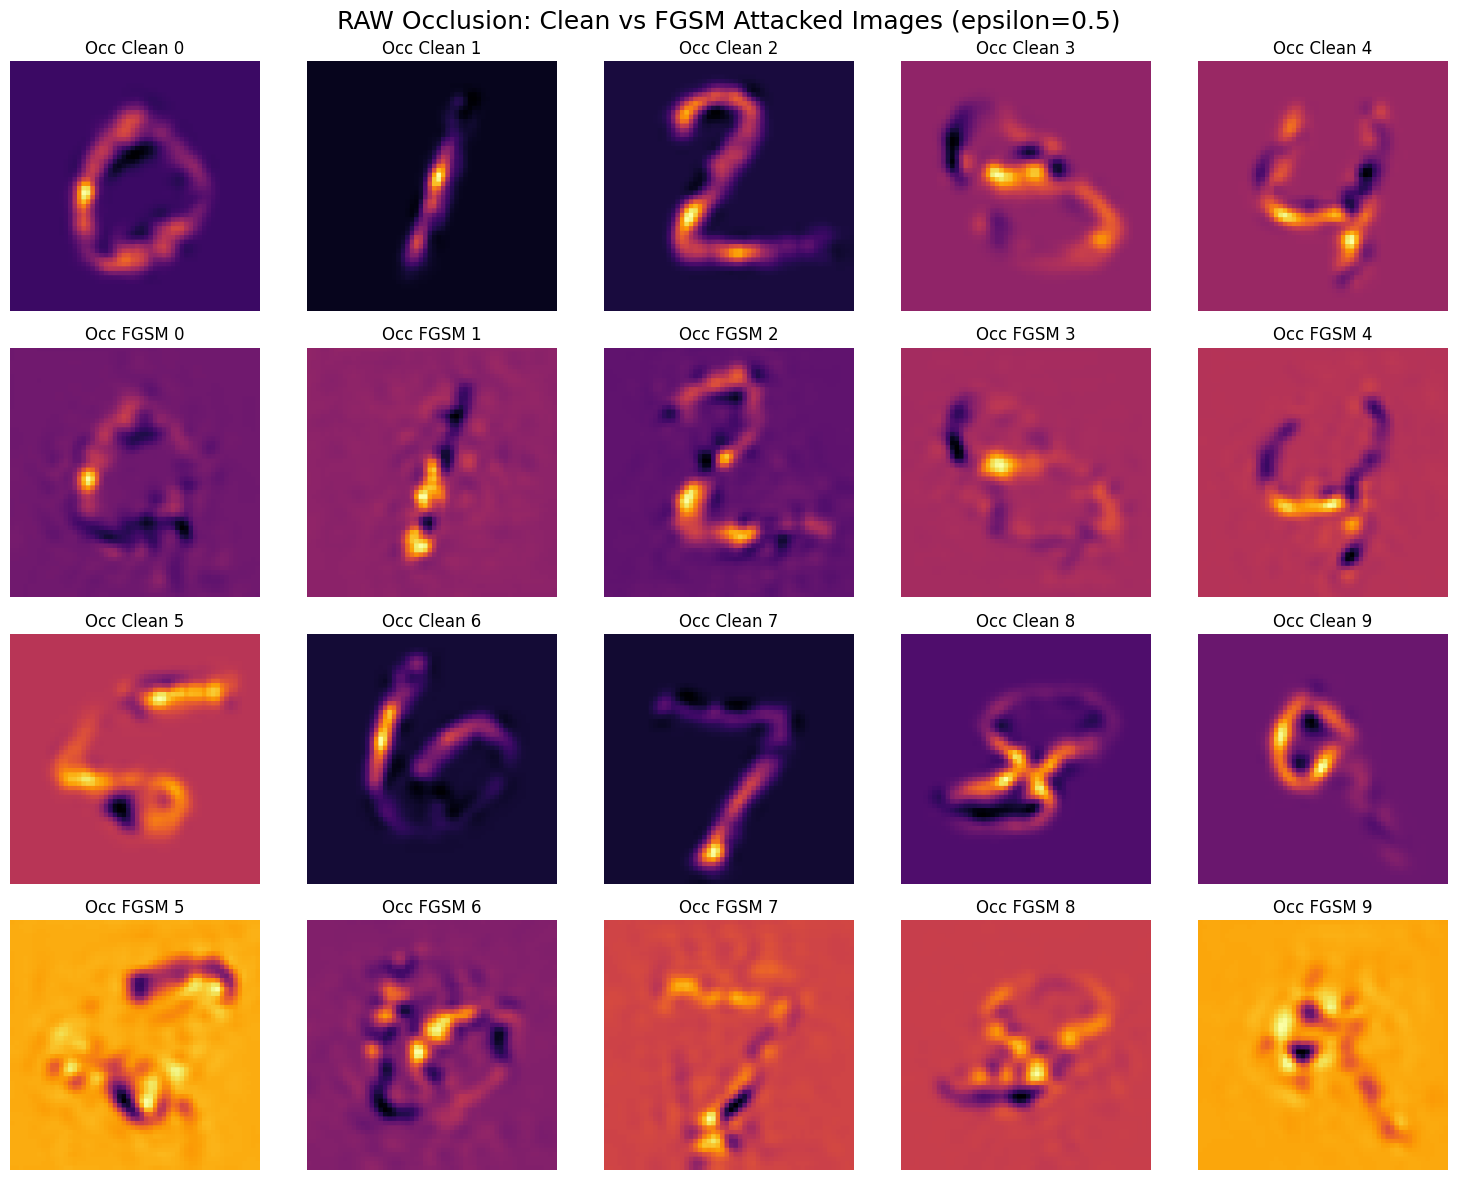

In [15]:
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle(
    f"RAW Occlusion: Clean vs FGSM Attacked Images (epsilon={epsilon})", fontsize=18
)

for digit in range(10):
    col = digit % 5

    if digit < 5:
        row_clean = 0
        row_attacked = 1
    else:
        row_clean = 2
        row_attacked = 3

    # --- CLEAN ---
    clean_tensor = clean_examples[digit].unsqueeze(0).to(device)
    baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)

    attr_clean_raw = occlusion.attribute(
        clean_tensor,
        strides=(3, 4, 4),
        sliding_window_shapes=(3, 12, 12),
        baselines=baseline_clean,
        target=digit,
    )

    clean_attr_np = process_attribution_raw(attr_clean_raw)

    plot_image(
        axes[row_clean, col],
        clean_attr_np,
        title=f"Occ Clean {digit}",
        cmap="inferno",
    )

    # --- FGSM ---
    attacked_tensor = fgsm_attack(
        model=model,
        input_tensor=clean_tensor,
        target_class=digit,
        epsilon=epsilon,
    )

    baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

    attr_attacked_raw = occlusion.attribute(
        attacked_tensor,
        strides=(3, 4, 4),
        sliding_window_shapes=(3, 12, 12),
        baselines=baseline_attacked,
        target=digit,
    )

    attacked_attr_np = process_attribution_raw(attr_attacked_raw)

    plot_image(
        axes[row_attacked, col],
        attacked_attr_np,
        title=f"Occ FGSM {digit}",
        cmap="inferno",
    )

plt.tight_layout()
plt.show()

In [17]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1]

all_occ_fgsm_cosine_results = []

for epsilon in epsilon_values:
    for digit in range(10):
        clean_tensor = clean_examples[digit].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=digit,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        # --- OCCLUSION CLEAN ---
        attr_clean_raw = occlusion.attribute(
            clean_tensor,
            strides=(3, 4, 4),
            sliding_window_shapes=(3, 12, 12),
            baselines=baseline_clean,
            target=digit,
        )

        # --- OCCLUSION FGSM ---
        attr_attacked_raw = occlusion.attribute(
            attacked_tensor,
            strides=(3, 4, 4),
            sliding_window_shapes=(3, 12, 12),
            baselines=baseline_attacked,
            target=digit,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        score = cosine_sim(clean_attr_np, attacked_attr_np)

        all_occ_fgsm_cosine_results.append(
            {
                "Epsilon": epsilon,
                "Digit": digit,
                "CosineSimilarity": score,
            }
        )

df_occ_fgsm_cosine = pd.DataFrame(all_occ_fgsm_cosine_results)

df_occ_fgsm_cosine_pivot = df_occ_fgsm_cosine.pivot(
    index="Epsilon",
    columns="Digit",
    values="CosineSimilarity",
)

df_occ_fgsm_cosine_summary = (
    df_occ_fgsm_cosine.groupby("Epsilon")["CosineSimilarity"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "MeanCosineSimilarity",
            "std": "StdCosineSimilarity",
        }
    )
)

print("=== Occlusion + FGSM: Cosine Similarity per digit ===")
display(df_occ_fgsm_cosine_pivot.round(3))

print("\n=== Occlusion + FGSM: Cosine Similarity summary ===")
display(df_occ_fgsm_cosine_summary.round(3))

=== Occlusion + FGSM: Cosine Similarity per digit ===


Digit,0,1,2,3,4,5,6,7,8,9
Epsilon,,,,,,,,,,
0.001,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
0.005,1.000,1.000,1.000,0.999,0.999,0.999,1.000,1.000,1.000,1.000
0.010,0.999,1.000,1.000,0.998,0.995,0.998,1.000,1.000,0.999,1.000
0.050,0.986,0.995,0.997,0.977,0.918,0.963,0.994,0.994,0.990,0.990
0.100,0.944,0.956,0.990,0.953,0.805,0.894,0.975,0.979,0.966,0.968



=== Occlusion + FGSM: Cosine Similarity summary ===


,Epsilon,MeanCosineSimilarity,StdCosineSimilarity
0,0.001,1.000,0.000
1,0.005,1.000,0.000
2,0.010,0.999,0.001
3,0.050,0.980,0.024
4,0.100,0.943,0.055


In [18]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1]

all_occ_fgsm_iou_results = []

for epsilon in epsilon_values:
    for digit in range(10):
        clean_tensor = clean_examples[digit].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=digit,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        # --- OCCLUSION CLEAN ---
        attr_clean_raw = occlusion.attribute(
            clean_tensor,
            strides=(3, 4, 4),
            sliding_window_shapes=(3, 12, 12),
            baselines=baseline_clean,
            target=digit,
        )

        # --- OCCLUSION FGSM ---
        attr_attacked_raw = occlusion.attribute(
            attacked_tensor,
            strides=(3, 4, 4),
            sliding_window_shapes=(3, 12, 12),
            baselines=baseline_attacked,
            target=digit,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        iou_score = topk_iou(
            clean_attr_np,
            attacked_attr_np,
            top_k_percent=0.10,
        )

        all_occ_fgsm_iou_results.append(
            {
                "Epsilon": epsilon,
                "Digit": digit,
                "TopK_IoU": iou_score,
            }
        )

df_occ_fgsm_iou = pd.DataFrame(all_occ_fgsm_iou_results)

df_occ_fgsm_iou_pivot = df_occ_fgsm_iou.pivot(
    index="Epsilon",
    columns="Digit",
    values="TopK_IoU",
)

df_occ_fgsm_iou_summary = (
    df_occ_fgsm_iou.groupby("Epsilon")["TopK_IoU"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "MeanTopK_IoU",
            "std": "StdTopK_IoU",
        }
    )
)

print("=== Occlusion + FGSM: Top-K IoU per digit ===")
display(df_occ_fgsm_iou_pivot.round(3))

print("\n=== Occlusion + FGSM: Top-K IoU summary ===")
display(df_occ_fgsm_iou_summary.round(3))

=== Occlusion + FGSM: Top-K IoU per digit ===


Digit,0,1,2,3,4,5,6,7,8,9
Epsilon,,,,,,,,,,
0.001,0.996,0.998,0.994,0.996,0.994,0.996,0.997,0.997,0.996,0.994
0.005,0.978,0.987,0.991,0.971,0.972,0.987,0.981,0.987,0.978,0.991
0.010,0.953,0.971,0.985,0.965,0.950,0.969,0.972,0.978,0.975,0.987
0.050,0.852,0.877,0.932,0.874,0.769,0.839,0.891,0.900,0.915,0.909
0.100,0.757,0.749,0.860,0.820,0.607,0.711,0.820,0.833,0.880,0.841



=== Occlusion + FGSM: Top-K IoU summary ===


,Epsilon,MeanTopK_IoU,StdTopK_IoU
0,0.001,0.996,0.002
1,0.005,0.982,0.007
2,0.010,0.971,0.012
3,0.050,0.876,0.047
4,0.100,0.788,0.083


In [19]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1]

all_occ_fgsm_deletion_results = []

for epsilon in epsilon_values:
    print(f"Processing epsilon={epsilon}")

    for digit in range(10):
        clean_tensor = clean_examples[digit].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=digit,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        # --- PREDICTIONS / CONFIDENCE ---
        with torch.no_grad():
            clean_output = model(clean_tensor)
            attacked_output = model(attacked_tensor)

            clean_pred = clean_output.argmax(dim=1).item()
            attacked_pred = attacked_output.argmax(dim=1).item()

            clean_conf = torch.softmax(clean_output, dim=1)[0, digit].item()

            attacked_conf = torch.softmax(attacked_output, dim=1)[0, digit].item()

        # --- OCCLUSION CLEAN ---
        attr_clean_raw = occlusion.attribute(
            clean_tensor,
            strides=(3, 4, 4),
            sliding_window_shapes=(3, 12, 12),
            baselines=baseline_clean,
            target=digit,
        )

        # --- OCCLUSION FGSM ---
        attr_attacked_raw = occlusion.attribute(
            attacked_tensor,
            strides=(3, 4, 4),
            sliding_window_shapes=(3, 12, 12),
            baselines=baseline_attacked,
            target=digit,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        # --- DELETION AUC ---
        deletion_clean = deletion_auc(
            model=model,
            input_tensor=clean_tensor,
            attribution_map=clean_attr_np,
            target_class=digit,
            steps=20,
            baseline_value=-1.0,
        )

        deletion_attacked = deletion_auc(
            model=model,
            input_tensor=attacked_tensor,
            attribution_map=attacked_attr_np,
            target_class=digit,
            steps=20,
            baseline_value=-1.0,
        )

        all_occ_fgsm_deletion_results.append(
            {
                "Epsilon": epsilon,
                "Digit": digit,
                "CleanPred": clean_pred,
                "AttackedPred": attacked_pred,
                "PredictionChanged": clean_pred != attacked_pred,
                "CleanConfidence": clean_conf,
                "AttackedConfidence": attacked_conf,
                "DeletionAUC_Clean": deletion_clean,
                "DeletionAUC_Attacked": deletion_attacked,
            }
        )

df_occ_fgsm_deletion = pd.DataFrame(all_occ_fgsm_deletion_results)

df_occ_fgsm_deletion_attacked_pivot = df_occ_fgsm_deletion.pivot(
    index="Epsilon",
    columns="Digit",
    values="DeletionAUC_Attacked",
)

df_occ_fgsm_deletion_summary = df_occ_fgsm_deletion.groupby("Epsilon").agg(
    CleanAUC_Mean=("DeletionAUC_Clean", "mean"),
    CleanAUC_Std=("DeletionAUC_Clean", "std"),
    AttackedAUC_Mean=("DeletionAUC_Attacked", "mean"),
    AttackedAUC_Std=("DeletionAUC_Attacked", "std"),
    AttackedConfidence_Mean=("AttackedConfidence", "mean"),
    PredictionChanges=("PredictionChanged", "sum"),
)

print("=== Occlusion + FGSM: Deletion AUC per digit ===")
display(df_occ_fgsm_deletion_attacked_pivot.round(3))

print("\n=== Occlusion + FGSM: Deletion AUC summary ===")
display(df_occ_fgsm_deletion_summary.round(3))

Processing epsilon=0.001
Processing epsilon=0.005
Processing epsilon=0.01
Processing epsilon=0.05
Processing epsilon=0.1
=== Occlusion + FGSM: Deletion AUC per digit ===


Digit,0,1,2,3,4,5,6,7,8,9
Epsilon,,,,,,,,,,
0.001,0.161,1.000,0.132,0.094,0.091,0.190,0.161,0.098,0.042,0.061
0.005,0.150,1.000,0.131,0.097,0.093,0.227,0.154,0.098,0.040,0.057
0.010,0.141,1.000,0.131,0.101,0.099,0.237,0.153,0.096,0.043,0.052
0.050,0.089,1.000,0.125,0.082,0.170,0.189,0.154,0.073,0.032,0.032
0.100,0.052,0.995,0.108,0.079,0.144,0.075,0.269,0.058,0.034,0.028



=== Occlusion + FGSM: Deletion AUC summary ===


,CleanAUC_Mean,CleanAUC_Std,AttackedAUC_Mean,AttackedAUC_Std,AttackedConfidence_Mean,PredictionChanges
Epsilon,,,,,,
0.001,0.201,0.285,0.203,0.284,1.000,0
0.005,0.201,0.285,0.205,0.284,1.000,0
0.010,0.201,0.285,0.205,0.285,1.000,0
0.050,0.201,0.285,0.195,0.288,0.997,0
0.100,0.201,0.285,0.184,0.294,0.929,1
